In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## X_TRAIN - VIZ

In [3]:
x_train = pd.read_csv("../data/x_train_final.csv")
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [4]:
x_train.describe()

# Unamed a tej

,Unnamed: 0.1,Unnamed: 0,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
count,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000,667264.000000
mean,333631.500000,333631.500000,18.277499,-0.170696,-0.167304,-0.176308,-0.163223,-0.173579,-0.174436
std,192622.669348,192622.669348,7.030424,1.976521,1.960416,1.926275,1.988527,2.643148,4.732999
min,0.000000,0.000000,7.000000,-160.000000,-160.000000,-160.000000,-160.000000,-1441.000000,-1441.000000
25%,166815.750000,166815.750000,12.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,333631.500000,333631.500000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,500447.250000,500447.250000,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,667263.000000,667263.000000,42.000000,14.000000,15.000000,15.000000,15.000000,15.000000,15.000000


In [5]:
# Nan values

x_train.isna().sum()

Unnamed: 0.1    0
Unnamed: 0      0
train           0
gare            0
date            0
arret           0
p2q0            0
p3q0            0
p4q0            0
p0q2            0
p0q3            0
p0q4            0
dtype: int64

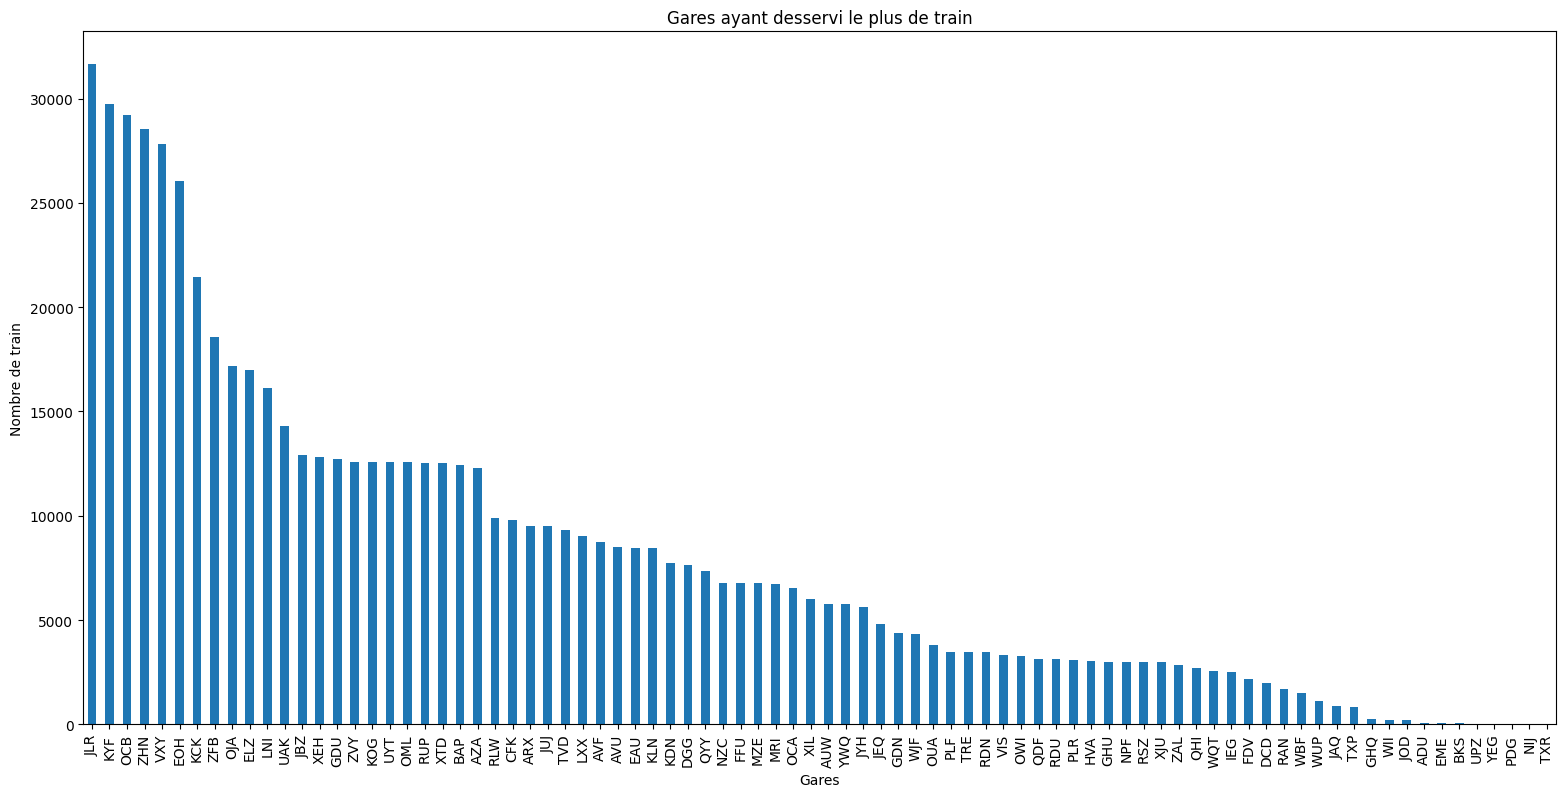

La gare ayant desservi le plus de train est  : JLR


In [35]:
plt.figure(figsize=(19,9))

x_train["gare"].value_counts().plot(kind="bar")
plt.title("Gares ayant desservi le plus de train")
plt.xlabel("Gares")
plt.ylabel("Nombre de train")
plt.show()

most_served_train_station = x_train["gare"].value_counts().sort_values(ascending=False).index[0]

print(f"La gare ayant desservi le plus de train est  : {most_served_train_station}")

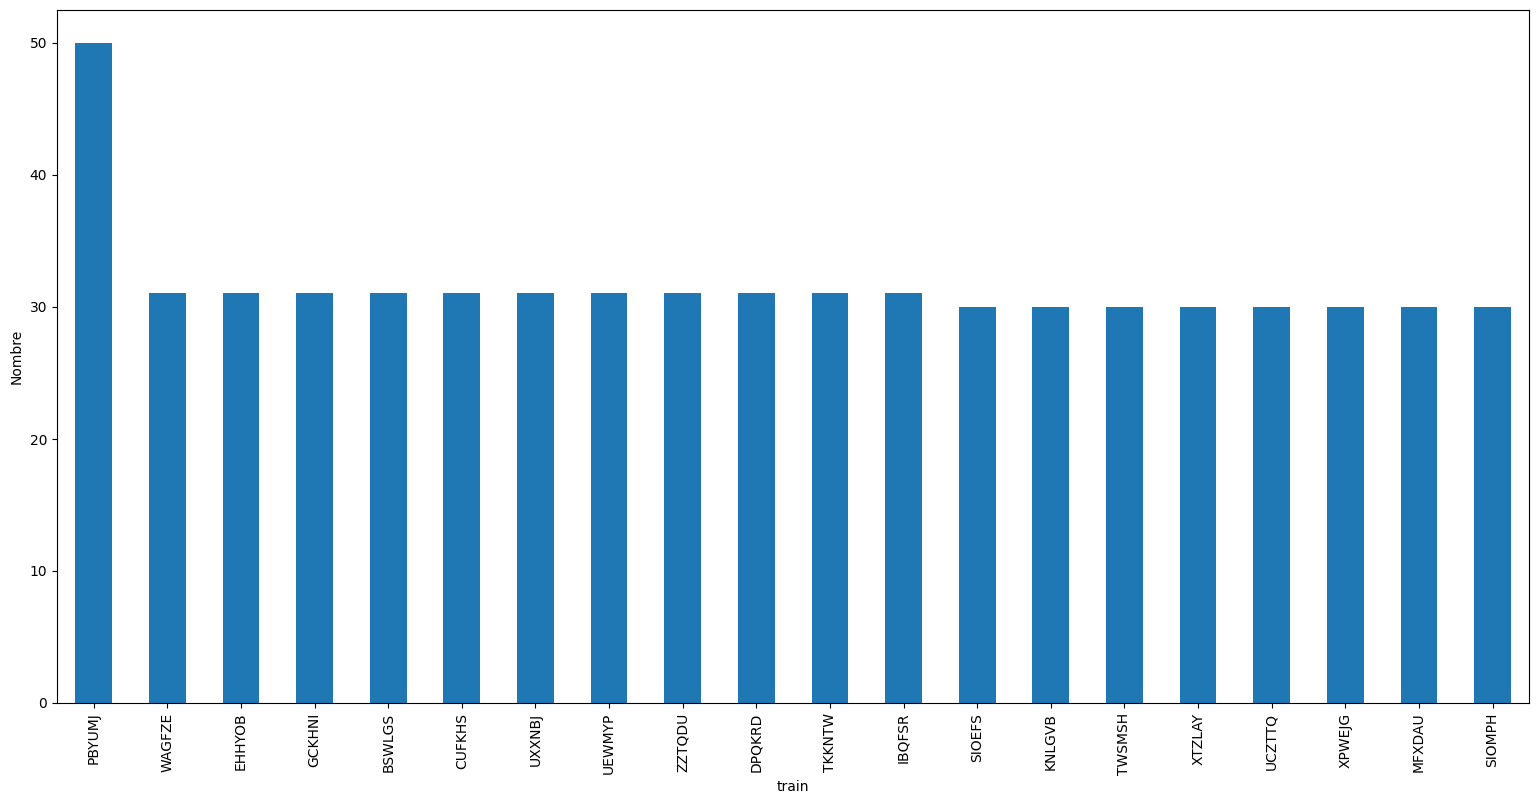

Le train le plus desservi est PBYUMJ !


In [32]:
plt.figure(figsize=(19,9))

x_train["train"].value_counts().head(20).plot(kind="bar")
plt.ylabel("Nombre")
plt.show()

most_served_train = x_train["train"].value_counts().sort_values(ascending=False).index[0]

print(f"Le train le plus desservi est {most_served_train} !")

In [39]:
x_train[(x_train["train"] == "PBYUMJ") & (x_train["gare"] == "JLR")] # Le train PBYUMJ est desservi deux fois sur la gare JLR

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
98693,98693,98693,PBYUMJ,JLR,2023-05-09,12,0.0,0.0,0.0,0.0,0.0,1.0
236402,236402,236402,PBYUMJ,JLR,2023-06-06,23,0.0,0.0,0.0,0.0,-1.0,1.0


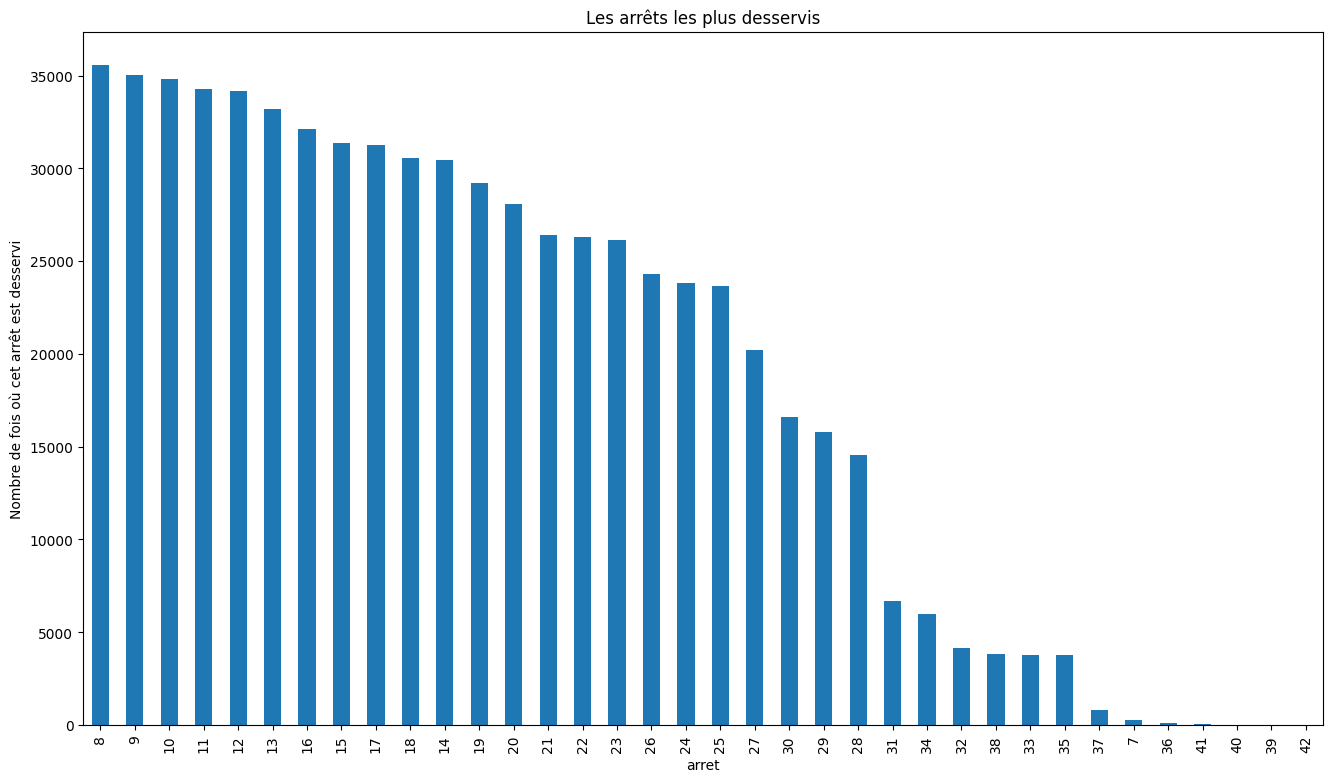

L'arrêt le plus desservi est le 8


In [43]:
plt.figure(figsize=(16,9))

x_train["arret"].value_counts().plot(kind="bar")
plt.title("Les arrêts les plus desservis")
plt.ylabel("Nombre de fois où cet arrêt est desservi")
plt.show()

most_served_stop = x_train['arret'].value_counts().sort_values(ascending=False).index[0]

print(f"L'arrêt le plus desservi est le {most_served_stop}")

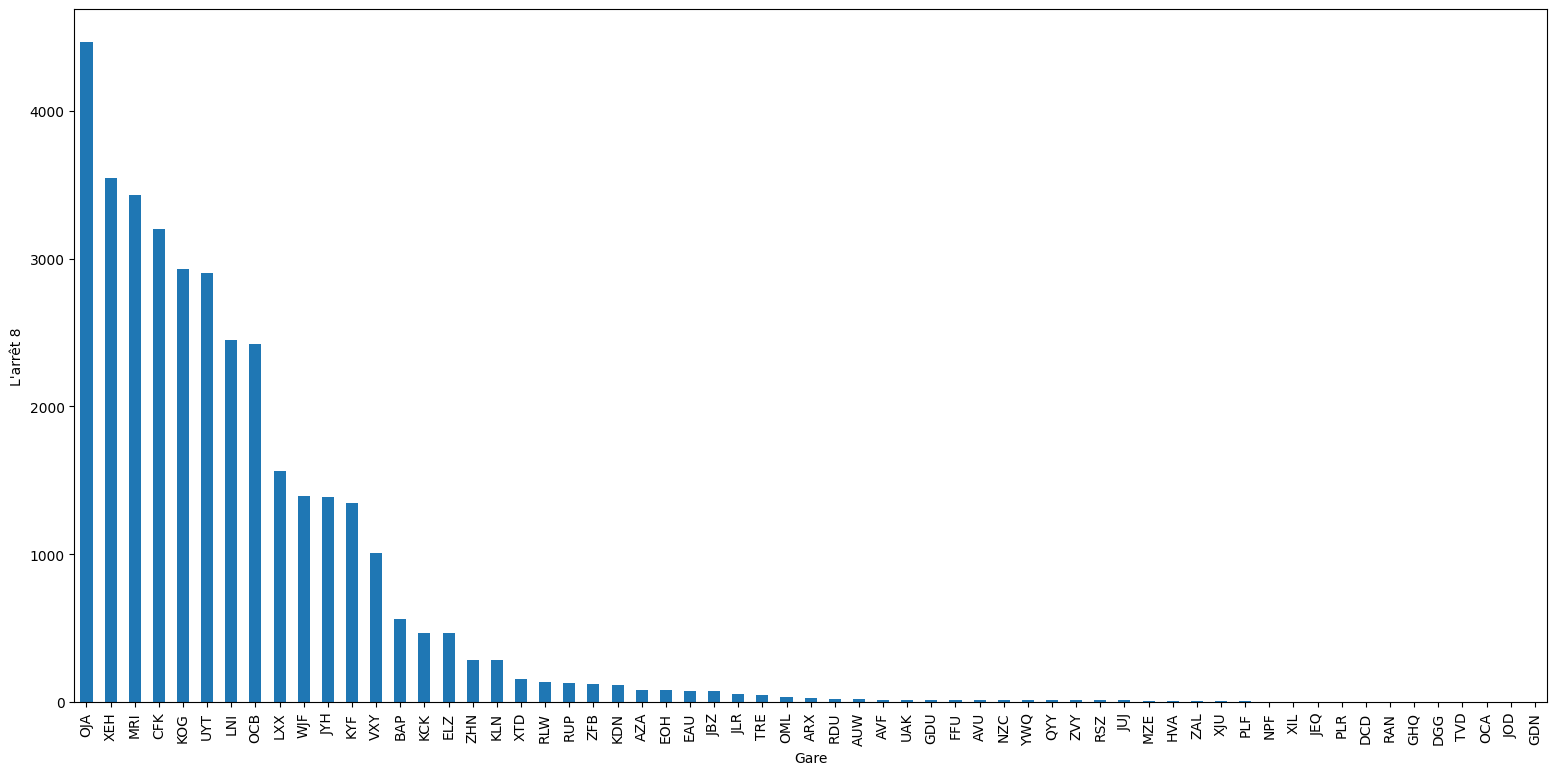

In [51]:
plt.figure(figsize=(19,9))
x_train[x_train["arret"] == 8]["gare"].value_counts().plot(kind="bar")
plt.xlabel("Gare")
plt.ylabel("L'arrêt 8")
plt.show()

In [53]:
x_train["date"]  = pd.to_datetime(x_train["date"])

In [55]:
x_train["year"] = x_train["date"].dt.year
x_train["month"] = x_train["date"].dt.month
x_train["day"] = x_train["date"].dt.day
x_train["day_of_week"] = x_train["date"].dt.dayofweek

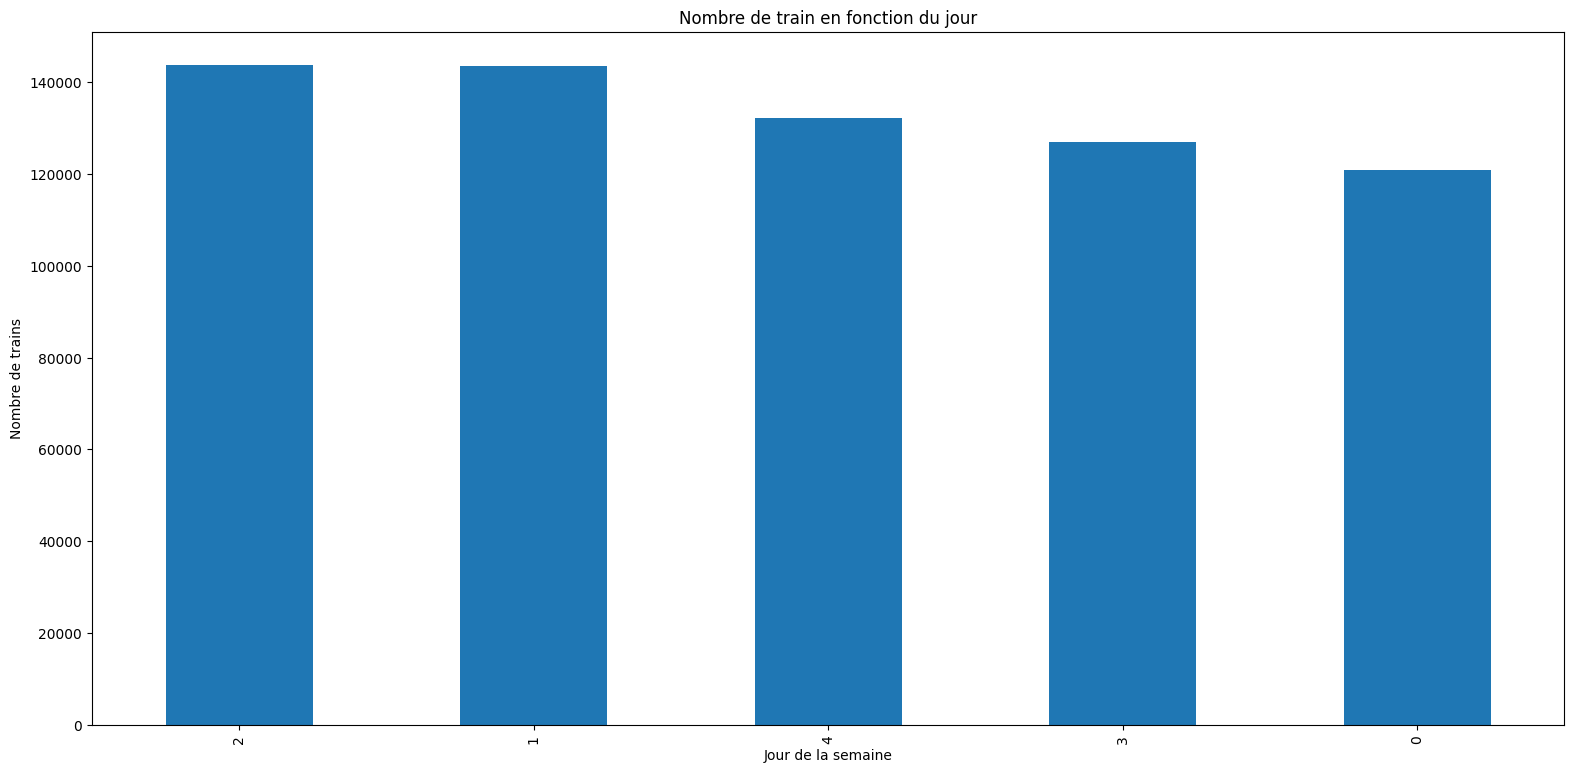

In [69]:
plt.figure(figsize=(19,9))

x_train["day_of_week"].value_counts().plot(kind="bar")
plt.title("Nombre de train en fonction du jour")
plt.xlabel("Jour de la semaine")
plt.ylabel("Nombre de trains")
plt.show()

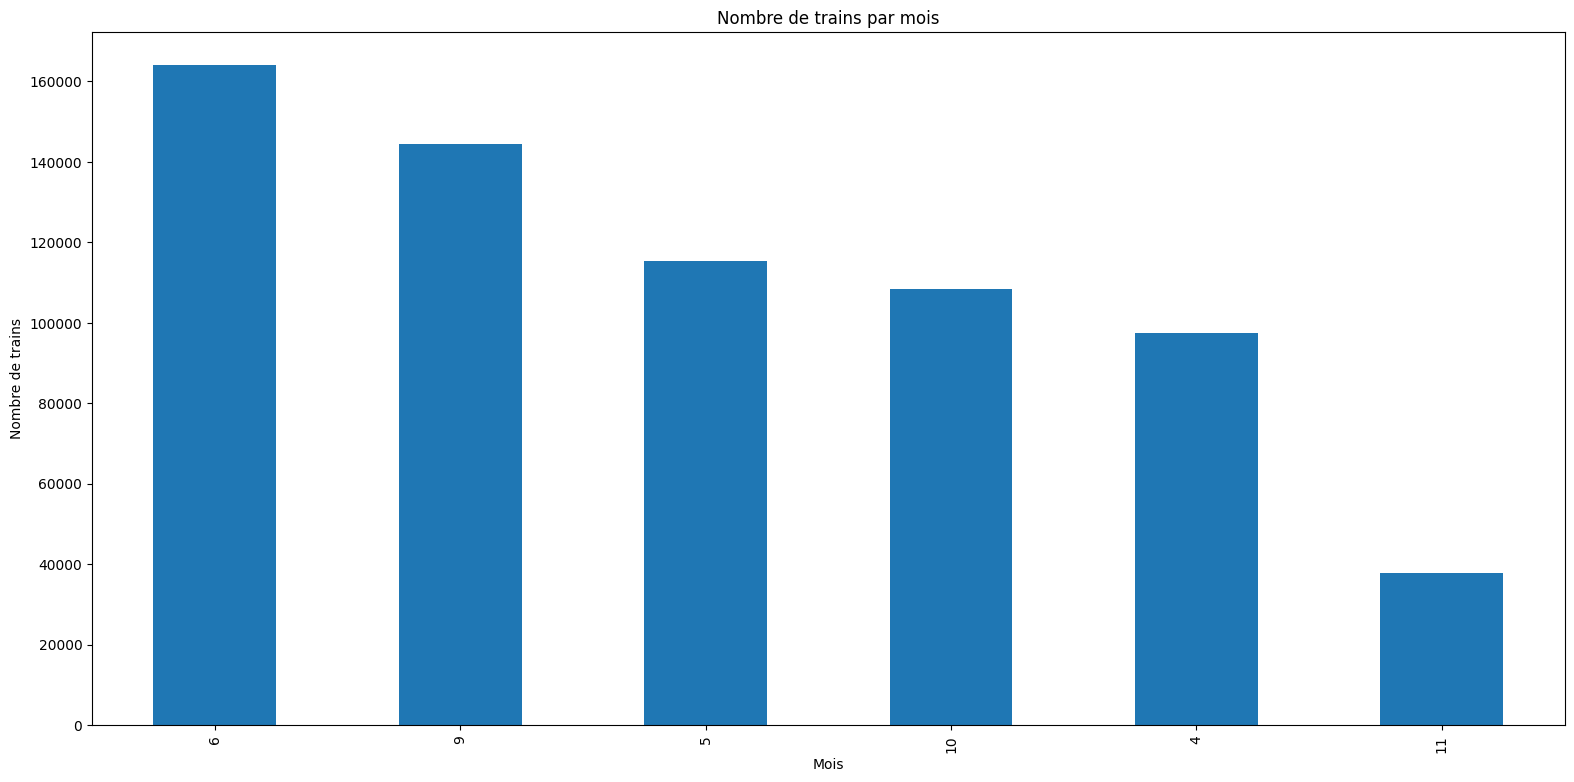

In [67]:
plt.figure(figsize=(19,9))

x_train["month"].value_counts().plot(kind="bar")
plt.title("Nombre de trains par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de trains")
plt.show()

In [ ]:
# Encodage cyclique
x_train["month_sin"] = np.sin(2 * np.pi * x_train["month"] / 12)
x_train["month_cos"] = np.cos(2 * np.pi * x_train["month"] / 12)
x_train["day_of_week_sin"] = np.sin(2 * np.pi * x_train["day_of_week"] / 5)
x_train["day_of_week_cos"] = np.cos(2 * np.pi * x_train["day_of_week"] / 5)

In [81]:
x_train_cpy = x_train.drop(columns=["Unnamed: 0.1" , "Unnamed: 0" , "year" , "date" , "day_of_week","month" ,"day"])

In [ ]:
x_train_cpy

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,VBXNMF,KYF,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,1.000000
1,VBXNMF,JLR,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,1.000000
2,VBXNMF,EOH,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,1.000000
3,VBXNMF,VXY,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,1.000000
4,VBXNMF,OCB,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,BFNJJK,DGG,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.951057,0.309017
667260,BFNJJK,KDN,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.951057,0.309017
667261,BFNJJK,TVD,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.951057,0.309017
667262,BFNJJK,TXP,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.951057,0.309017


In [115]:
# Retard de train : p2q0 . Nous allons fixer la gare s à TVD . retard du train k-2 à la gare s

p2q0 = x_train_cpy[x_train_cpy["gare"] == "TVD"]["p2q0"]

mean_late = p2q0.mean()
max_late = np.abs(p2q0.min())
min_late = p2q0.max()

print(f"Nous avons en moyenne {mean_late} minutes de retard pour la gare TVD !")
print(f"Nous avons au maximum {max_late} minutes de retard pour la gare TVD ! ")
print(f"Nous avons au maximum {min_late} minutes d'avance pour la gare TVD ! ")

Nous avons en moyenne 0.38915675559841423 minutes de retard pour la gare TVD !
Nous avons au maximum 75.0 minutes de retard pour la gare TVD ! 
Nous avons au maximum 5.0 minutes d'avance pour la gare TVD ! 


In [120]:
# Retard du même train k pour toutes les gares qu'il a déja traversées. p0q2 = retard du train k à la gare s-2 . On fixe le train k : PBYUMJ

p0q2 = x_train_cpy[x_train_cpy["train"] == "PBYUMJ"]["p0q2"]

mean_late = p0q2.mean()
max_late = np.abs(p0q2.min())
min_late = p0q2.max()

print(f"Nous avons en moyenne {mean_late} minutes de retard pour le train PBYUMJ pour la gare s-2 !")
print(f"Nous avons au maximum {max_late} minutes de retard pour le train PBYUMJ pour la gare s-2 !")
print(f"Nous avons au maximum {min_late} minutes d'avance pour le train PBYUMJ pour la gare s-2 !")

Nous avons en moyenne -0.2 minutes de retard pour le train PBYUMJ pour la gare s-2 !
Nous avons au maximum 3.0 minutes de retard pour le train PBYUMJ pour la gare s-2 !
Nous avons au maximum 2.0 minutes d'avance pour le train PBYUMJ pour la gare s-2 !


In [122]:
# Check des outliers

x_train_cpy[x_train_cpy["p0q3"] <= -1000]

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
315111,JXNGKF,VXY,21,-2.0,0.0,2.0,-2.0,-1441.0,0.0,1.224647e-16,-1.0,0.587785,-0.809017


In [ ]:
x_train_cpy[x_train_cpy["p0q4"] <= -1000] # HMM BIZARRE ???

,train,gare,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos
115576,LRDJCC,GDN,21,0.0,1.0,1.0,0.0,0.0,-1440.0,5.000000e-01,-0.866025,-0.587785,-0.809017
153537,FTYMLQ,JLR,10,-1.0,-1.0,-1.0,0.0,0.0,-1438.0,5.000000e-01,-0.866025,-0.951057,0.309017
153561,OASJIF,GDN,21,-1.0,0.0,0.0,0.0,1.0,-1439.0,5.000000e-01,-0.866025,-0.951057,0.309017
315121,YQWYHB,AVF,14,0.0,0.0,-1.0,0.0,1.0,-1440.0,1.224647e-16,-1.000000,0.587785,-0.809017
315340,SBVADY,JLR,12,0.0,0.0,-1.0,0.0,0.0,-1440.0,1.224647e-16,-1.000000,0.587785,-0.809017
322157,NOATQT,VXY,15,-1.0,0.0,0.0,0.0,-2.0,-1441.0,1.224647e-16,-1.000000,0.587785,-0.809017


## ## Y_TRAIN - VIZ

In [ ]:
y_train = pd.read_csv("../data/y_train_final.csv")
y_train = y_train.drop(columns=["Unnamed: 0"])

In [86]:
y_train

,p0q0
0,-1.0
1,-1.0
2,-1.0
3,1.0
4,3.0
...,...
667259,1.0
667260,2.0
667261,2.0
667262,1.0
